In [1]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split


In [2]:
with open("mnist_small.pickle", "rb") as file:
    data = pickle.load(file)

In [3]:
_X = data["_X"].astype(np.float64)
_Y = data["_Y"].astype(np.int32)
print(_X.shape)
print(_X.dtype)
print(_Y.shape)
print(_Y.dtype)

(4000, 1, 28, 28)
float64
(4000, 1)
int32


In [4]:
# Split data into train and test sets
_X_train, _X_test, _Y_train, _Y_test = train_test_split(
    _X, _Y, test_size=0.2, random_state=42
)
print(_X_train.shape)
print(_Y_train.shape)
print(_X_test.shape)
print(_Y_test.shape)

(3200, 1, 28, 28)
(3200, 1)
(800, 1, 28, 28)
(800, 1)


In [5]:
def scaler_transform(X):
    _mean = np.mean(X)
    _std = np.std(X)
    return (X - _mean) / _std


In [6]:
# Scale the data
# Note that we don't use SKLearn's StandardScaler here because our data is 4D and SKLearn's StandardScaler only works with 2D data.
# Therefore, we have to do it manually. We need to calculate mean and std of the training data.
_mean = np.mean(_X_train)
_std = np.std(_X_train)
print(f"Mean: {_mean}, Std: {_std}")

Mean: 33.14677574936224, Std: 78.34915146880222


In [7]:
# Scale the X data
X_train = (_X_train - _mean) / _std
X_test = (_X_test - _mean) / _std

# Check the range of X before and after scaling
print("_X_train (before scaling):", _X_train.min(), "to", _X_train.max())
print("X_train (after scaling):", X_train.min(), "to", X_train.max())

# No scaling for labels
Y_train = _Y_train
Y_test = _Y_test


_X_train (before scaling): 0.0 to 255.0
X_train (after scaling): -0.4230648976787059 to 2.831597025514403


In [8]:
# Convert to PyTorch tensors
X_train_pt = torch.tensor(X_train, dtype=torch.float32)
X_test_pt = torch.tensor(X_test, dtype=torch.float32)

# For labels, we need to convert them to long type because CrossEntropyLoss expects the target labels to be of type long.
Y_train_pt = torch.tensor(Y_train, dtype=torch.long)
Y_test_pt = torch.tensor(Y_test, dtype=torch.long)

In [9]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.max_pool = nn.MaxPool2d(2)
        self.relu = nn.ReLU()
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.fc1 = nn.Linear(32 * 4 * 4, num_classes)

    def forward(self, X):
        X = self.conv1(X)
        X = self.relu(X)
        X = self.max_pool(X)
        X = self.conv2(X)
        X = self.relu(X)
        X = self.max_pool(X)
        X = self.adaptive_pool(X)
        X = X.view(X.shape[0], -1)
        X = self.fc1(X)
        return X


model = SimpleCNN(num_classes=10)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

In [10]:
# Function to get batches of indices
def get_batches_indices(num_samples, batch_size):
    indices = np.arange(num_samples)
    np.random.shuffle(indices)
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples)
        batch_indices = indices[start_idx:end_idx]
        yield batch_indices


# Example usage
num_samples = 20
batch_size = 6
for idxes in get_batches_indices(num_samples, batch_size):
    print(idxes)


[ 7 14  2 12 10  4]
[ 8 13  6  5 11 16]
[ 9  3  1 19  0 15]
[18 17]


In [11]:
def calc_metrices(logits: torch.Tensor, labels: torch.Tensor, isPrint=False):
    # Apply softmax to logits to obtain prediction probabilities for each class
    probs = F.softmax(logits, dim=1)  # Shape: (batch_size, num_classes)

    # Use argmax to get the predicted class index for each sample
    preds = torch.argmax(probs, dim=1)  # Shape: (batch_size)

    # Move prediction and label tensors to CPU and convert to numpy arrays for scikit-learn compatibility
    preds_np = preds.cpu().numpy()
    labels_np = labels.cpu().numpy()

    # Generate the classification report as a dictionary (includes precision, recall, f1, etc.)
    report = classification_report(labels_np, preds_np, output_dict=True)

    # Optionally print a nicely formatted classification report if isPrint is True
    if isPrint:
        print(classification_report(labels_np, preds_np, digits=3))

    # Return the report dictionary and the numpy arrays of predictions and labels
    return report, preds_np, labels_np

In [12]:
loss_arr = []
F1_arr = []

In [13]:
n_epochs = 20  # number of epochs to run
batch_size = 10  # size of each batch

for epoch in range(n_epochs):
    # Training Phase
    model.train()
    epoch_train_loss = 0.0
    epoch_train_f1 = 0.0
    logit_arr = []
    label_arr = []

    for idxes in get_batches_indices(len(X_train_pt), batch_size):
        X_batch_pt = X_train_pt[idxes]
        Y_batch_pt = Y_train_pt[idxes]
        optimizer.zero_grad()
        Y_pred = model(X_batch_pt)
        loss = loss_fn(
            Y_pred, Y_batch_pt.view(-1)
        )  # view(-1) is used to flatten the labels to the shape (batch_size, ) which is required by CrossEntropyLoss
        # Backward pass
        loss.backward()

        # Optional gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping

        # Update weights
        optimizer.step()
        # Multiplies the average loss per sample by the number of
        # samples in the batch to get the total loss for this batch.
        epoch_train_loss += loss.item() * len(idxes)
        logit_arr.append(Y_pred)
        label_arr.append(Y_batch_pt)

    avg_train_loss = epoch_train_loss / len(X_train)
    loss_arr.append(avg_train_loss)

    logits = torch.concat(logit_arr, dim=0)
    labels = torch.concat(label_arr, dim=0)
    metrices, _, _ = calc_metrices(logits=logits, labels=labels.view(-1))
    avg_train_f1 = metrices["weighted avg"]["f1-score"]
    F1_arr.append(avg_train_f1)

    print(
        f"Epoch {epoch + 1}/{n_epochs}, Training Loss: {avg_train_loss:.4f}, Training F1-Score: {avg_train_f1:.4f}"
    )

Epoch 1/20, Training Loss: 1.0552, Training F1-Score: 0.6604
Epoch 2/20, Training Loss: 0.3669, Training F1-Score: 0.8833
Epoch 3/20, Training Loss: 0.2371, Training F1-Score: 0.9250
Epoch 4/20, Training Loss: 0.1860, Training F1-Score: 0.9417
Epoch 5/20, Training Loss: 0.1669, Training F1-Score: 0.9481
Epoch 6/20, Training Loss: 0.1435, Training F1-Score: 0.9550
Epoch 7/20, Training Loss: 0.1236, Training F1-Score: 0.9640
Epoch 8/20, Training Loss: 0.1113, Training F1-Score: 0.9669
Epoch 9/20, Training Loss: 0.0990, Training F1-Score: 0.9679
Epoch 10/20, Training Loss: 0.1033, Training F1-Score: 0.9706
Epoch 11/20, Training Loss: 0.0855, Training F1-Score: 0.9775
Epoch 12/20, Training Loss: 0.0829, Training F1-Score: 0.9756
Epoch 13/20, Training Loss: 0.0719, Training F1-Score: 0.9788
Epoch 14/20, Training Loss: 0.0776, Training F1-Score: 0.9778
Epoch 15/20, Training Loss: 0.0581, Training F1-Score: 0.9837
Epoch 16/20, Training Loss: 0.0560, Training F1-Score: 0.9844
Epoch 17/20, Trai

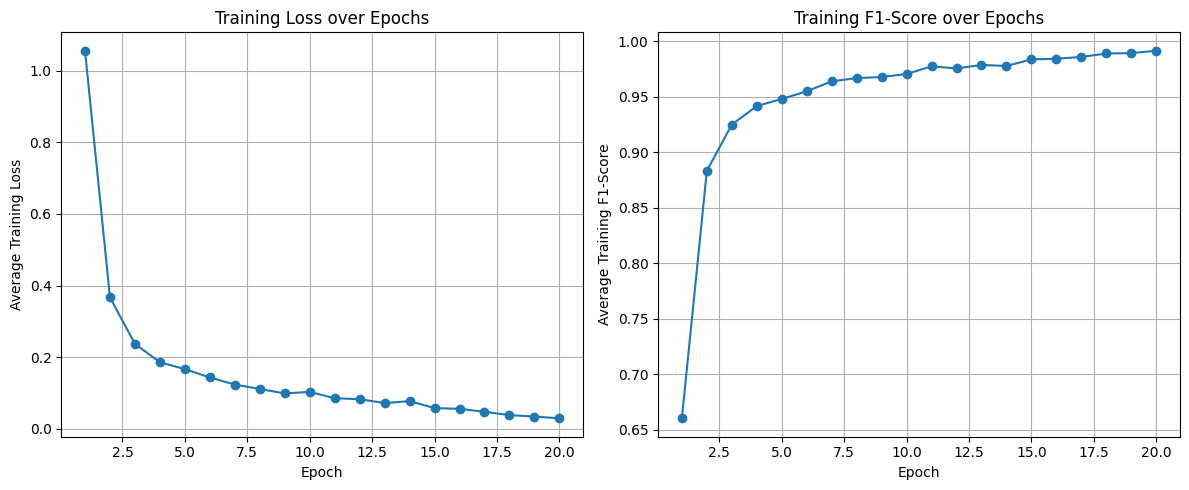

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(range(1, len(loss_arr) + 1), loss_arr, marker="o")
axes[0].set_title("Training Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Average Training Loss")
axes[0].grid()

axes[1].plot(range(1, len(F1_arr) + 1), F1_arr, marker="o")
axes[1].set_title("Training F1-Score over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Average Training F1-Score")
axes[1].grid()

plt.tight_layout()
plt.show()

In [15]:
# Evaluation Phase
model.eval()
with torch.no_grad():
    Y_pred_test = model(X_test_pt)
    test_loss = loss_fn(Y_pred_test, Y_test_pt.view(-1)).item()
    report, preds_np, labels_np = calc_metrices(
        logits=Y_pred_test, labels=Y_test_pt.view(-1), isPrint=False
    )

print(f"Test Loss: {test_loss:.4f}")
print(f"Test F1-Score: {report['weighted avg']['f1-score']:.4f}")

Test Loss: 0.2474
Test F1-Score: 0.9453


Number of misclassified samples: 44


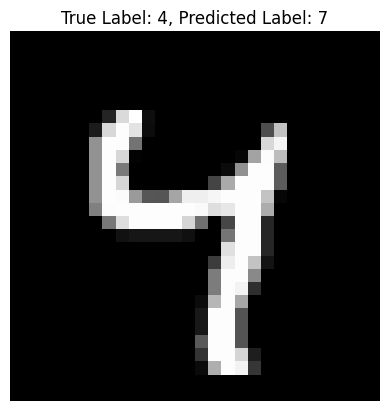

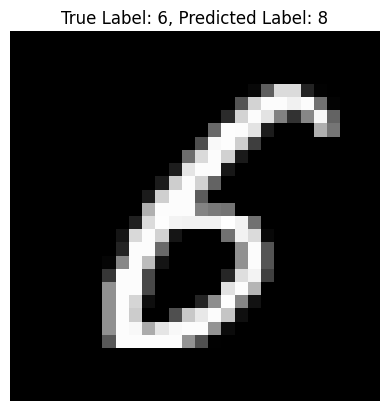

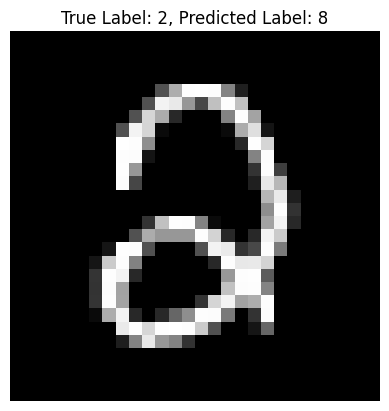

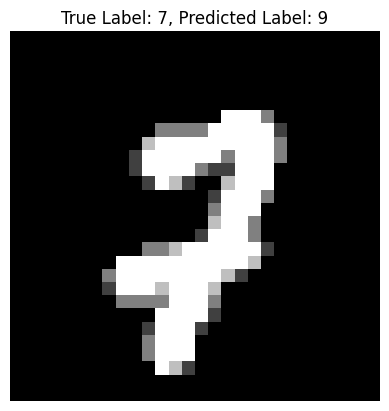

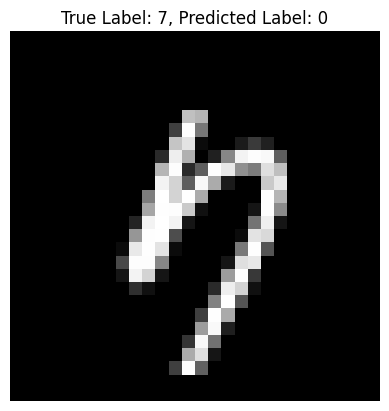

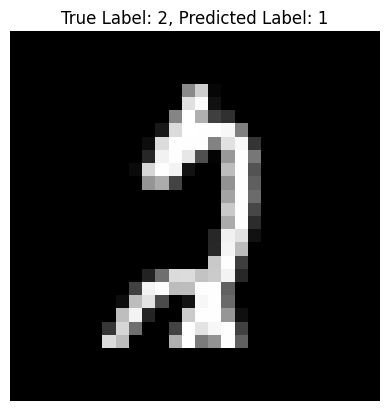

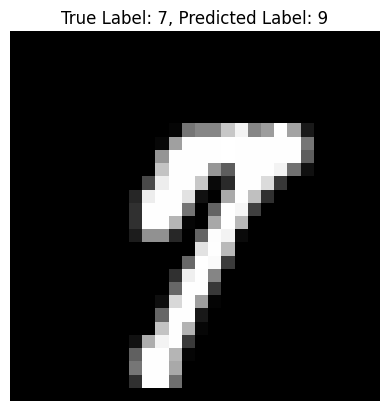

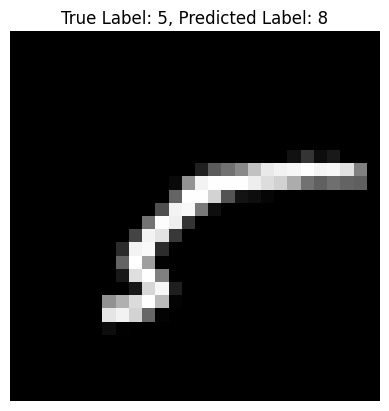

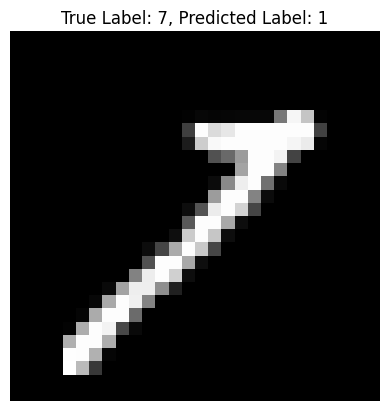

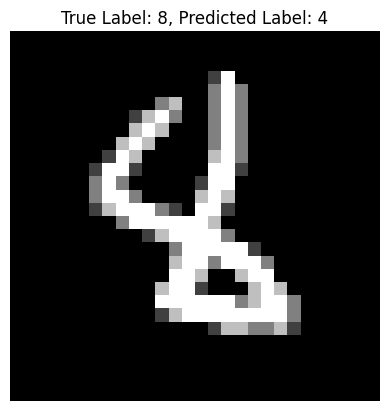

In [16]:
# Investigate misclassified samples
misclassified_indices = np.where(preds_np != labels_np)[0]
print(f"Number of misclassified samples: {len(misclassified_indices)}")

# Visualize some misclassified samples
num_samples_to_show = min(10, len(misclassified_indices))
for i in range(num_samples_to_show):
    idx = misclassified_indices[i]
    plt.imshow(X_test[idx].squeeze(), cmap="gray")
    plt.title(
        f"True Label: {labels_np[idx]}, Predicted Label: {preds_np[idx]}"
    )
    plt.axis("off")
    plt.show()  